In [37]:
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt


from collections import defaultdict
from skimage.feature import local_binary_pattern


from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [38]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
IMAGE_DIR = "/content/drive/MyDrive/Floor Segmentation.v4i.coco-segmentation/train"
COCO_JSON = "/content/drive/MyDrive/Floor Segmentation.v4i.coco-segmentation/train/_annotations.coco.json"

In [40]:
from pycocotools.coco import COCO
coco = COCO(COCO_JSON)
print(f"Images: {len(coco.imgs)}, Floor anns: {len(coco.getAnnIds())}")

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
Images: 694, Floor anns: 1089


In [41]:
cat_ids = coco.getCatIds(catNms=['floor'])
print(f"Floor category IDs: {cat_ids}")
img_ids = coco.getImgIds(catIds=cat_ids)
print(f"Images with floor annotations: {len(img_ids)}")

Floor category IDs: [0, 1]
Images with floor annotations: 0


In [42]:
# Print all categories
cats = coco.loadCats(coco.getCatIds())
print("All categories:", cats)

# Check first few annotations
ann_ids = coco.getAnnIds()[:5]
sample_anns = coco.loadAnns(ann_ids)
for ann in sample_anns:
    print(f"Ann ID {ann['id']}: image_id={ann['image_id']}, category_id={ann['category_id']}")

All categories: [{'id': 0, 'name': 'floor', 'supercategory': 'none'}, {'id': 1, 'name': 'floor', 'supercategory': 'floor'}]
Ann ID 0: image_id=0, category_id=1
Ann ID 1: image_id=0, category_id=1
Ann ID 2: image_id=0, category_id=1
Ann ID 3: image_id=1, category_id=1
Ann ID 4: image_id=2, category_id=1


In [43]:
import cv2
import numpy as np

PATCH_SIZE = 64
floor_patches = []

cat_ids = [0, 1]  # Both your floor categories
img_ids = list(coco.imgs.keys())

print("Extracting floor patches...")
for i, img_id in enumerate(img_ids):
    img_info = coco.loadImgs(img_id)[0]
    img_path = f"{IMAGE_DIR}/{img_info['file_name']}"
    img = cv2.imread(img_path)
    if img is None:
        print(f"Failed to load {img_path}")
        continue

    # Get ALL annotations for this image
    ann_ids_img = coco.getAnnIds(imgIds=img_id)
    anns_img = coco.loadAnns(ann_ids_img)

    # Filter FLOOR annotations only
    floor_anns = [ann for ann in anns_img if ann['category_id'] in cat_ids]

    for ann in floor_anns:
        mask = coco.annToMask(ann)
        contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for cnt in contours:
            x,y,w,h = cv2.boundingRect(cnt)
            if w >= 32 and h >= 32:  # Min size filter
                x1, y1 = max(0, x), max(0, y)
                x2, y2 = min(img.shape[1], x+w), min(img.shape[0], y+h)
                if x2-x1 >= PATCH_SIZE//2 and y2-y1 >= PATCH_SIZE//2:
                    patch = cv2.resize(img[y1:y2, x1:x2], (PATCH_SIZE, PATCH_SIZE))
                    floor_patches.append(patch)

    if i % 10 == 0:
        print(f"Processed {i+1}/694 images, {len(floor_patches)} floor patches")

print(f"✅ Total floor patches extracted: {len(floor_patches)}")

Extracting floor patches...
Processed 1/694 images, 3 floor patches
Processed 11/694 images, 15 floor patches
Processed 21/694 images, 31 floor patches
Processed 31/694 images, 42 floor patches
Processed 41/694 images, 56 floor patches
Processed 51/694 images, 69 floor patches
Processed 61/694 images, 82 floor patches
Processed 71/694 images, 95 floor patches
Processed 81/694 images, 107 floor patches
Processed 91/694 images, 119 floor patches
Processed 101/694 images, 133 floor patches
Processed 111/694 images, 147 floor patches
Processed 121/694 images, 160 floor patches
Processed 131/694 images, 171 floor patches
Processed 141/694 images, 184 floor patches
Processed 151/694 images, 196 floor patches
Processed 161/694 images, 212 floor patches
Processed 171/694 images, 227 floor patches
Processed 181/694 images, 238 floor patches
Processed 191/694 images, 249 floor patches
Processed 201/694 images, 262 floor patches
Processed 211/694 images, 275 floor patches
Processed 221/694 images

In [44]:
import numpy as np

PATCH_SIZE = 64
non_floor_patches = []

print("Extracting non-floor patches...")
for i, img_id in enumerate(img_ids):
    img_info = coco.loadImgs(img_id)[0]
    img_path = f"{IMAGE_DIR}/{img_info['file_name']}"
    img = cv2.imread(img_path)
    if img is None: continue

    # Create combined floor mask for this image
    ann_ids_img = coco.getAnnIds(imgIds=img_id)
    anns_img = coco.loadAnns(ann_ids_img)
    floor_mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)

    for ann in anns_img:
        if ann['category_id'] in [0, 1]:
            floor_mask += coco.annToMask(ann) > 0  # Binary OR

    # Sample non-floor patches (background regions)
    attempts = 0
    while len(non_floor_patches) < 131 and attempts < 1000:  # Match floor patches
        y = np.random.randint(0, img.shape[0]-PATCH_SIZE)
        x = np.random.randint(0, img.shape[1]-PATCH_SIZE)

        if floor_mask[y:y+PATCH_SIZE, x:x+PATCH_SIZE].sum() < PATCH_SIZE*PATCH_SIZE*0.3:  # <30% floor
            patch = cv2.resize(img[y:y+PATCH_SIZE, x:x+PATCH_SIZE], (PATCH_SIZE, PATCH_SIZE))
            non_floor_patches.append(patch)

        attempts += 1

    if i % 20 == 0:
        print(f"Processed {i+1}/694 images, {len(non_floor_patches)} non-floor patches")

print(f"✅ Total non-floor patches: {len(non_floor_patches)}")

Extracting non-floor patches...
Processed 1/694 images, 131 non-floor patches
Processed 21/694 images, 131 non-floor patches
Processed 41/694 images, 131 non-floor patches
Processed 61/694 images, 131 non-floor patches
Processed 81/694 images, 131 non-floor patches
Processed 101/694 images, 131 non-floor patches
Processed 121/694 images, 131 non-floor patches
Processed 141/694 images, 131 non-floor patches
Processed 161/694 images, 131 non-floor patches
Processed 181/694 images, 131 non-floor patches
Processed 201/694 images, 131 non-floor patches
Processed 221/694 images, 131 non-floor patches
Processed 241/694 images, 131 non-floor patches
Processed 261/694 images, 131 non-floor patches
Processed 281/694 images, 131 non-floor patches
Processed 301/694 images, 131 non-floor patches
Processed 321/694 images, 131 non-floor patches
Processed 341/694 images, 131 non-floor patches
Processed 361/694 images, 131 non-floor patches
Processed 381/694 images, 131 non-floor patches
Processed 401/

Extracting HOG features...
Total samples: 1048, Floor: 917, Non-floor: 131

📊 SVM Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.58      0.73        26
           1       0.94      1.00      0.97       184

    accuracy                           0.95       210
   macro avg       0.97      0.79      0.85       210
weighted avg       0.95      0.95      0.94       210

✅ Training accuracy: 1.000
✅ Test accuracy: 0.948


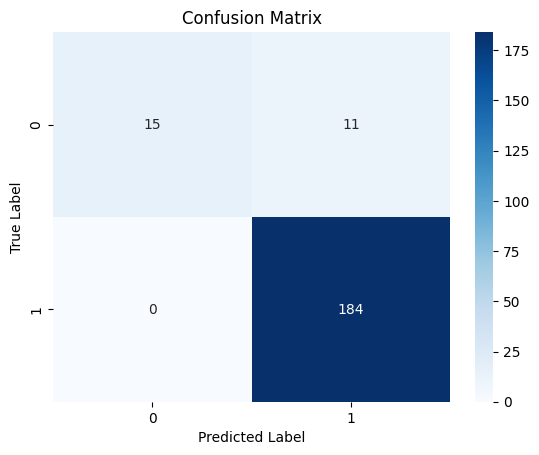

In [45]:
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Extract HOG features for ALL patches
print("Extracting HOG features...")
X, y = [], []
for patch in floor_patches:
    fd = hog(patch[:,:,0], orientations=9, pixels_per_cell=(8,8),
             cells_per_block=(2,2), visualize=False)
    X.append(fd); y.append(1)  # Floor = 1

for patch in non_floor_patches:
    fd = hog(patch[:,:,0], orientations=9, pixels_per_cell=(8,8),
             cells_per_block=(2,2), visualize=False)
    X.append(fd); y.append(0)  # Non-floor = 0

print(f"Total samples: {len(X)}, Floor: {y.count(1)}, Non-floor: {y.count(0)}")

# Split and train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
svm = SVC(kernel='rbf', C=10, probability=True, random_state=42)
svm.fit(X_train, y_train)

# Results
y_pred = svm.predict(X_test)
print("\n📊 SVM Classification Report:")
print(classification_report(y_test, y_pred))

print(f"✅ Training accuracy: {svm.score(X_train, y_train):.3f}")
print(f"✅ Test accuracy: {svm.score(X_test, y_test):.3f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

Generating floor mask...


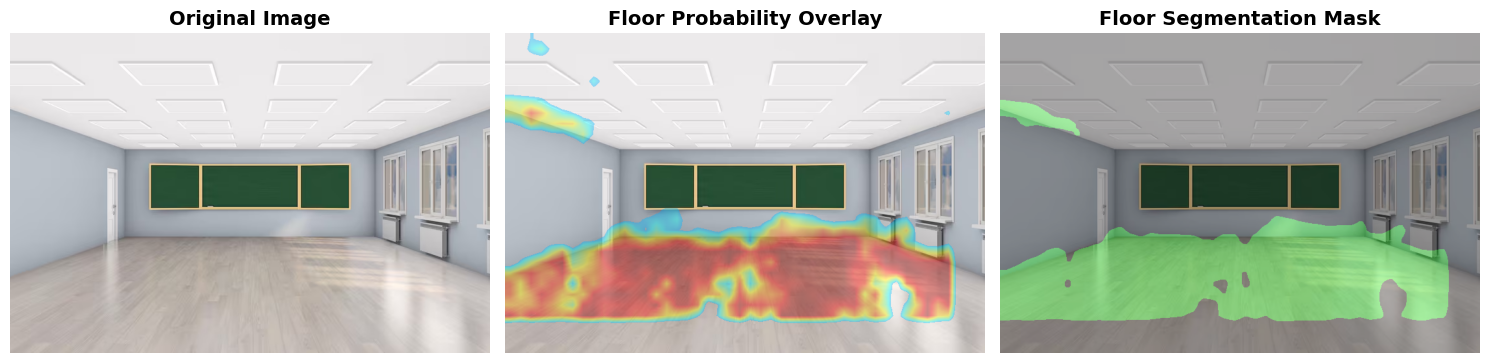

In [57]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def create_floor_mask(test_img_path, svm, PATCH_SIZE=64, stride=16, threshold=0.5):
    """Create clean floor segmentation mask from SVM predictions"""
    test_img = cv2.imread(test_img_path)
    h, w = test_img.shape[:2]

    # Prediction probability map
    prob_map = np.zeros((h//stride, w//stride))

    print("Generating floor mask...")
    for y in range(0, h-PATCH_SIZE, stride):
        for x in range(0, w-PATCH_SIZE, stride):
            patch = test_img[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
            fd = hog(patch[:,:,0], orientations=9, pixels_per_cell=(8,8), cells_per_block=(2,2))
            prob = svm.predict_proba([fd])[0][1]  # Floor probability
            prob_map[y//stride, x//stride] = prob

    # Upsample to full resolution
    prob_map_full = cv2.resize(prob_map, (w, h), interpolation=cv2.INTER_LINEAR)

    # Binary mask with smoothing
    binary_mask = (prob_map_full > threshold).astype(np.uint8)
    kernel = np.ones((5,5), np.uint8)
    binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel)
    binary_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel)

    return test_img, prob_map_full, binary_mask

# Test on your image (replace with actual path)
test_img_path = "/content/1.avif"  # Use one of your images
original_img, prob_map, floor_mask = create_floor_mask(test_img_path, svm)

# Professional 3-panel visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original image
axes[0].imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Probability heatmap (semi-transparent)
overlay = original_img.copy()
heatmap = cv2.applyColorMap((prob_map*255).astype(np.uint8), cv2.COLORMAP_JET)
alpha = 0.4
overlay[prob_map > 0.3] = cv2.addWeighted(overlay, 1-alpha, heatmap, alpha, 0)[prob_map > 0.3]
axes[1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
axes[1].set_title('Floor Probability Overlay', fontsize=14, fontweight='bold')
axes[1].axis('off')

# Clean binary mask overlay
mask_colored = np.zeros_like(original_img)
mask_colored[floor_mask == 1] = [0, 255, 0]  # Green floor
final_overlay = cv2.addWeighted(original_img, 0.7, mask_colored, 0.3, 0)
axes[2].imshow(cv2.cvtColor(final_overlay, cv2.COLOR_BGR2RGB))
axes[2].set_title('Floor Segmentation Mask', fontsize=14, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()
